# Chapitre 8 — Visualisation exploratoire

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Choisir** le type de graphique approprié selon la question et les données
2. **Créer** des visualisations avec Matplotlib et Seaborn
3. **Personnaliser** les graphiques pour une communication efficace
4. **Appliquer** les bonnes pratiques de visualisation (lisibilité, accessibilité)

---

## 8.2 Seaborn : visualisations statistiques

### Pourquoi Seaborn ?

Seaborn est construit sur Matplotlib mais offre :
- Des graphiques statistiques prêts à l'emploi
- Une meilleure esthétique par défaut
- Une intégration native avec pandas

In [20]:
import seaborn as sns

# Configurer le style
sns.set_theme(style="whitegrid")

---

### Distributions

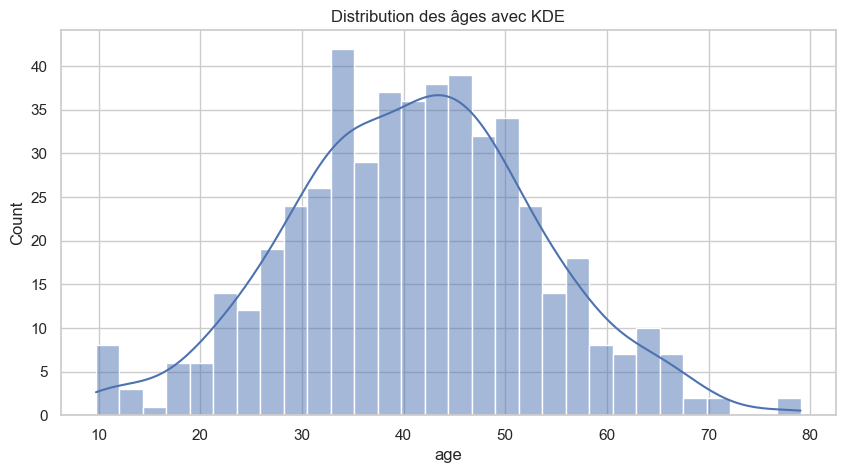

In [21]:
import pandas as pd
import numpy as np

# Données
df = pd.DataFrame({
    'age': np.random.normal(40, 12, 500),
    'revenus': np.random.exponential(50000, 500),
    'segment': np.random.choice(['A', 'B', 'C'], 500)
})

# HISTPLOT : histogramme amélioré
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True, bins=30)
plt.title('Distribution des âges avec KDE')
plt.show()

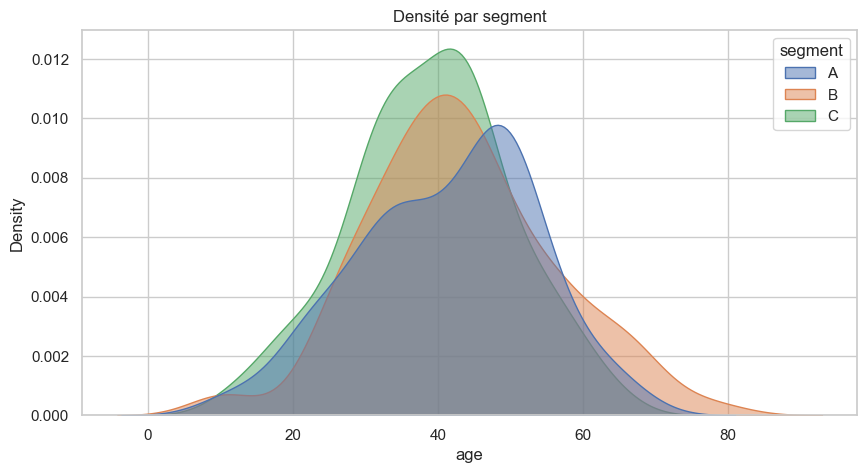

In [22]:
# KDEPLOT : courbe de densité
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='age', hue='segment', fill=True, alpha=0.5)
plt.title('Densité par segment')
plt.show()

# kdeplot : courbe de densité pour les revenus

KDE = Kernel Density Estimation (Estimation par noyau de densité)

C'est une méthode pour visualiser la distribution d'une variable continue sous forme de courbe lisse, au lieu d'un histogramme en barres.

Histogramme	KDE 
- Dépend du nombre de bins 
- Peut masquer des détails 
- Discret 

Avantages du KDE 
- Courbe continue
- Plus fluide et lisible
- Continu

En résumé : le KDE montre la forme de la distribution de manière plus élégante qu'un histogramme.



In [ ]:
# BOXPLOT : distribution + outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='segment', y='revenus')
plt.title('Revenus par segment')
plt.show()

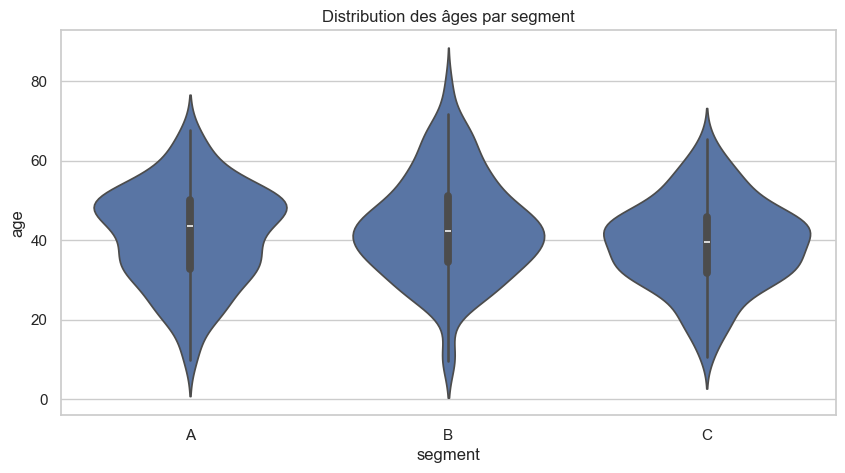

In [ ]:
# VIOLINPLOT : boxplot + densité
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='segment', y='age')
plt.title('Distribution des âges par segment')
plt.show()

# violinplot : distribution des âges par segment
# interpretation : 
# Le violinplot montre que le segment A a une distribution d'âges plus concentrée autour de la moyenne,
# tandis que le segment C a une distribution plus étalée avec des âges plus jeunes et plus âgés.

#Violinplot = Boxplot + KDE combinés
# C'est un graphique qui montre à la fois la distribution des données 
# et leurs statistiques (médiane, quartiles).

#Largeur	Densité (plus large = plus de données)
#Forme	Distribution (symétrique, bimodale, etc.)
#Centre	Médiane et quartiles (comme un boxplot)

# Boxplot : pour voir les outliers et comparer des médianes
# Violinplot : pour voir la forme de la distribution (bimodale ? asymétrique ?)

---

### Relations

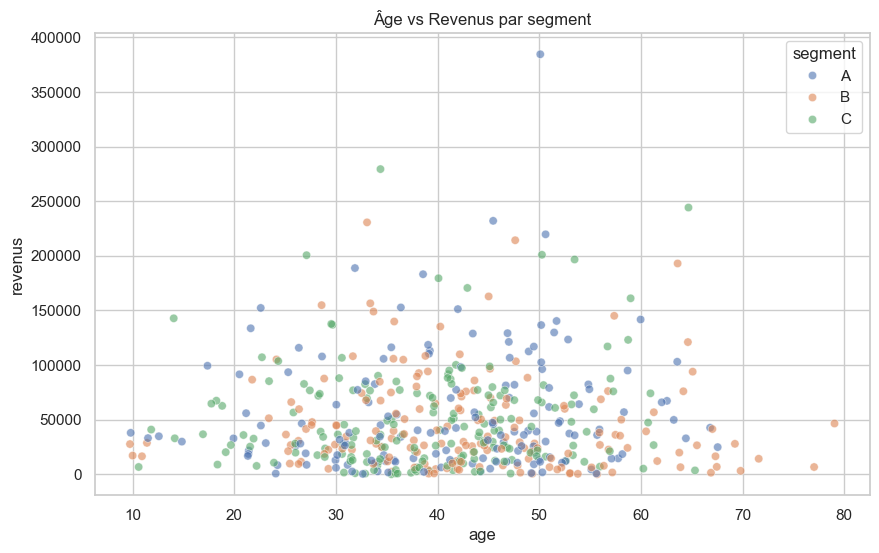

In [5]:
# SCATTERPLOT avec couleur
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='revenus', hue='segment', alpha=0.6)
plt.title('Âge vs Revenus par segment')
plt.show()

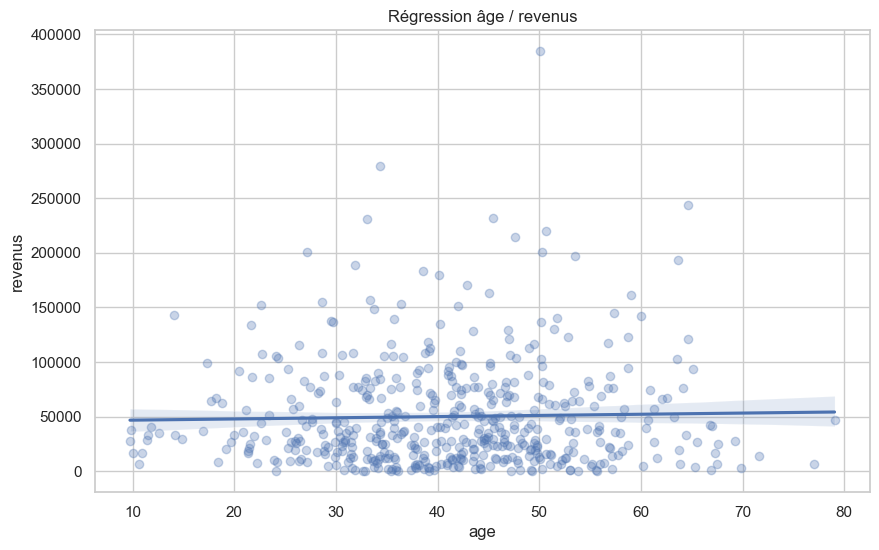

In [ ]:
# REGPLOT : scatter + régression linéaire
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='age', y='revenus', scatter_kws={'alpha':0.3})
plt.title('Régression âge / revenus')
plt.show()

# regplot : courbe de régression entre âge et revenus

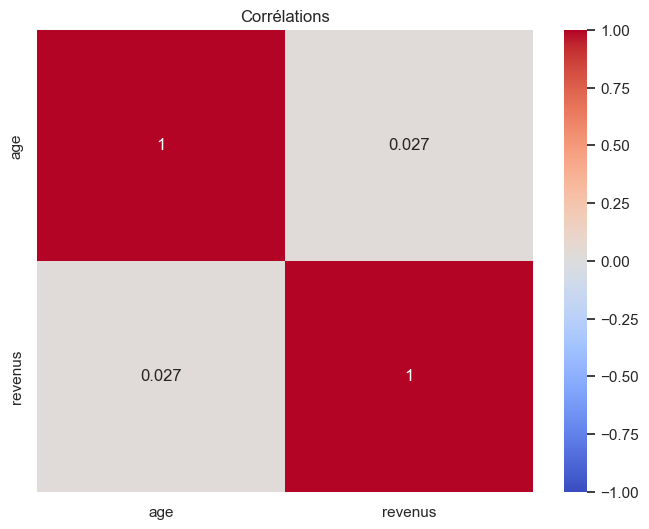

In [ ]:
# HEATMAP : matrice de corrélation
plt.figure(figsize=(8, 6))
corr_matrix = df[['age', 'revenus']].corr() #  la matrice de corrélation de Pearson entre les colonnes age et revenus. 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Corrélations')
plt.show()

# annot=True : affiche les valeurs numériques dans chaque cellule
# cmap='coolwarm' : palette de couleurs (bleu = négatif, rouge = positif)
# center=0 : le blanc est centré sur 0
# vmin=-1, vmax=1 : échelle fixée de -1 à 1 (plage des corrélations)

# Corrélation	Signification
# proche de 1	forte relation positive
# proche de -1	forte relation négative
# proche de 0	pas de relation linéaire

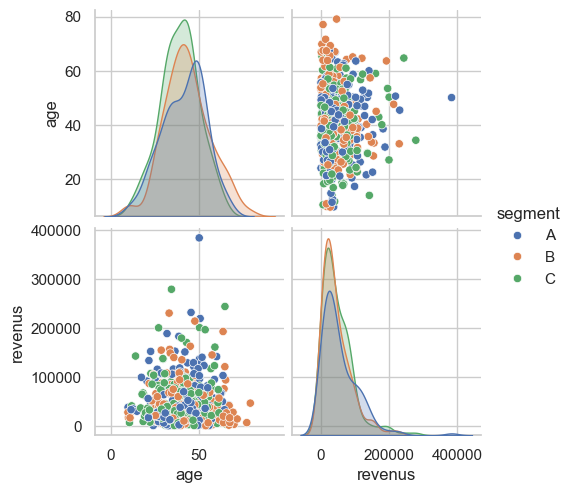

In [11]:
# PAIRPLOT : toutes les relations d'un coup
sns.pairplot(df, hue='segment', diag_kind='kde')
plt.show()

---

### Catégorielles

/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_54820/2810054547.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='segment', palette='Set2')


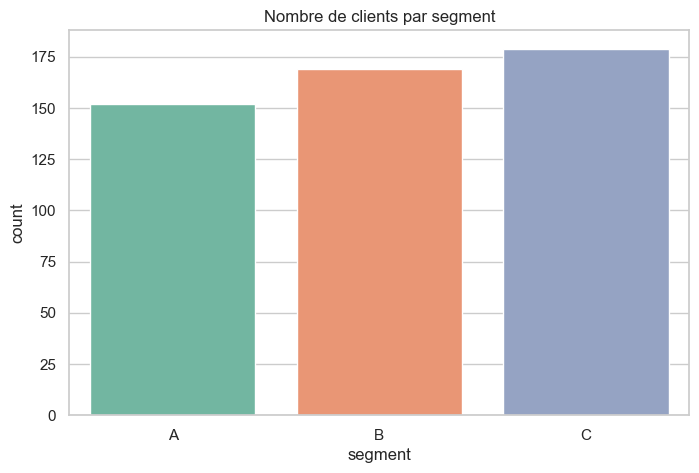

In [12]:
# COUNTPLOT : fréquences
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='segment', palette='Set2')
plt.title('Nombre de clients par segment')
plt.show()

/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_54820/1848503403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='segment', y='revenus', estimator=np.mean, palette='Blues')


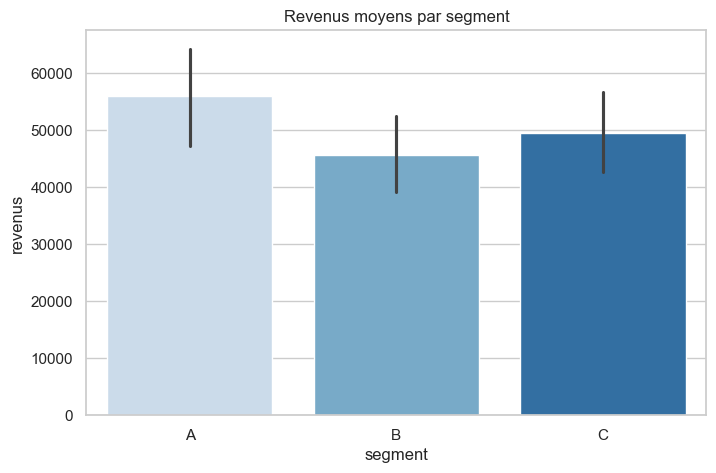

In [13]:
# BARPLOT : moyenne par catégorie
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='segment', y='revenus', estimator=np.mean, palette='Blues')
plt.title('Revenus moyens par segment')
plt.show()

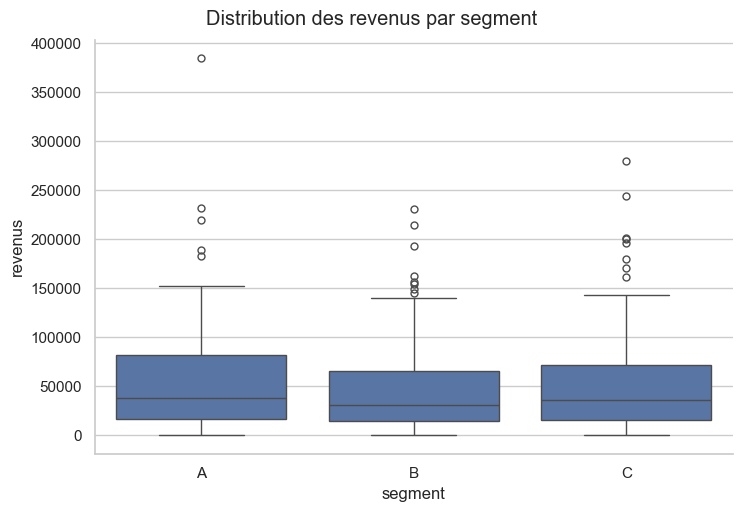

In [14]:
# CATPLOT : graphiques par catégorie (flexible)
g = sns.catplot(data=df, x='segment', y='revenus', kind='box', height=5, aspect=1.5)
g.fig.suptitle('Distribution des revenus par segment', y=1.02)
plt.show()

---

### ✍️ Exercice 8.2 : Visualisation Seaborn (20 min)

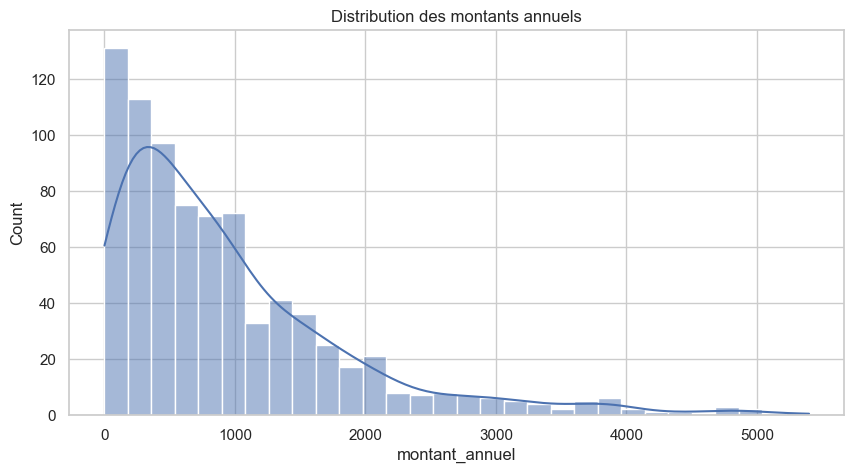

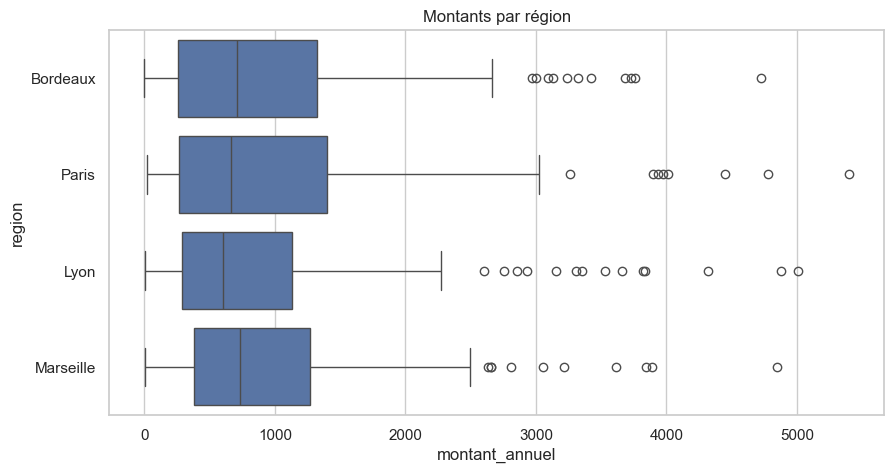

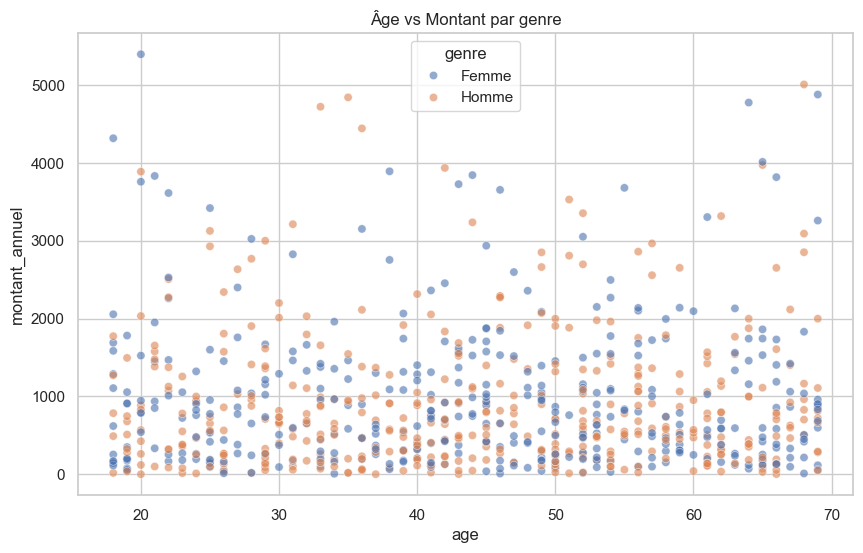

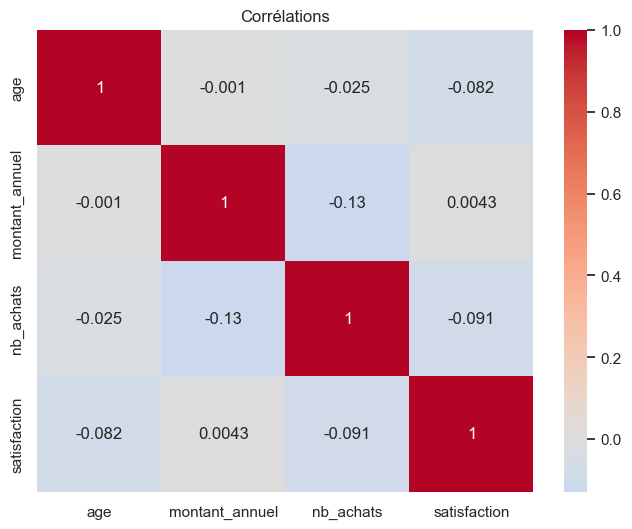

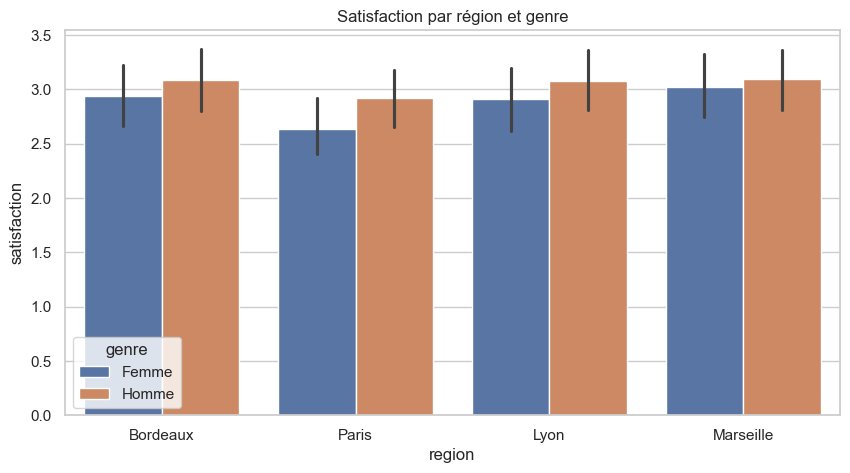

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Données clients
np.random.seed(42)
n = 800
df = pd.DataFrame({
    'client_id': range(n),
    'age': np.random.randint(18, 70, n),
    'genre': np.random.choice(['Homme', 'Femme'], n),
    'region': np.random.choice(['Paris', 'Lyon', 'Marseille', 'Bordeaux'], n),
    'montant_annuel': np.random.exponential(1000, n),
    'nb_achats': np.random.randint(1, 50, n),
    'satisfaction': np.random.randint(1, 6, n)
})

sns.set_theme(style="whitegrid")

# 1. Distribution des montants avec KDE
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='montant_annuel', kde=True, bins=30)
plt.title('Distribution des montants annuels')
plt.show()

# 2. Boxplot montant par région
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='montant_annuel', y='region')
plt.title('Montants par région')
plt.show()

# 3. Scatter age vs montant avec couleur par genre
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='montant_annuel', hue='genre', alpha=0.6)
plt.title('Âge vs Montant par genre')
plt.show()

# 4. Heatmap des corrélations numériques
plt.figure(figsize=(8, 6))
cols_num = ['age', 'montant_annuel', 'nb_achats', 'satisfaction']
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations')
plt.show()

# 5. Satisfaction moyenne par région et genre
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='region', y='satisfaction', hue='genre')
plt.title('Satisfaction par région et genre')
plt.show()